# Day 06 — Python → SQLite

Every project day from Day 07 on runs against a local `.sqlite` file instead of a MySQL server. Rather than meeting SQLite for the first time on an unfamiliar project dataset, this notebook first rebuilds the already-familiar `rawaj` as a local SQLite file, verifies the migration, then re-runs a full sweep through every Day 01-05 concept against the copy — plus safe parameter binding and some visualizations, since turning a query result into a chart is exactly the kind of thing Python adds that a plain SQL client can't.

**Before you start:** run `day06_python_mysql.ipynb` first, or at least its setup cell — this notebook reads from the same live MySQL connection to build the SQLite copy.

## Setup — reconnect to MySQL (the source data)

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd

load_dotenv()  # reads DB_PASSWORD from the local .env file

mysql_url = URL.create(
    "mysql+mysqlconnector",
    username="root",
    password=os.getenv("DB_PASSWORD"),
    host="localhost",
    port=3306,
    database="rawaj",
)
mysql_engine = create_engine(mysql_url, connect_args={"use_pure": True})

MySQL still needs SQLAlchemy here — `URL.create()` for safe credential encoding, and `use_pure` for the driver bug from `day06_python_mysql.ipynb`. That's a MySQL-specific need. SQLite is a different story, starting below.

## Section 1 — Migrating rawaj into a local SQLite file

**Business question:** a teammate without MySQL installed still needs to work with this data — hand them a single portable file instead.

The destination side uses Python's built-in `sqlite3` module directly — no SQLAlchemy, no extra install. `pandas.to_sql`/`read_sql` both accept a raw `sqlite3.Connection` just as happily as a SQLAlchemy engine.

In [2]:
import sqlite3

sqlite_conn = sqlite3.connect("rawaj.sqlite")

TABLES = ["governorates", "account_managers", "sellers", "customers", "orders", "web_events", "reviews"]
mysql_counts, sqlite_counts = {}, {}

for table in TABLES:
    df = pd.read_sql(text(f"SELECT * FROM {table}"), mysql_engine)
    mysql_counts[table] = len(df)
    df.to_sql(table, sqlite_conn, index=False, if_exists="replace")

sqlite_conn.commit()

`rawaj.sqlite` is generated here, not committed to git — regenerate it any time by re-running this cell, same reasoning as never committing `.env`.

**Verify the migration** — don't just assume it worked, check row-for-row that every table landed correctly.

In [3]:
for table in TABLES:
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", sqlite_conn)["n"][0]
    sqlite_counts[table] = int(count)

comparison = pd.DataFrame({"mysql_rows": mysql_counts, "sqlite_rows": sqlite_counts})
comparison["match"] = comparison["mysql_rows"] == comparison["sqlite_rows"]
comparison

,mysql_rows,sqlite_rows,match
governorates,6,6,True
account_managers,15,15,True
sellers,200,200,True
customers,1200,1200,True
orders,6000,6000,True
web_events,9000,9000,True
reviews,2792,2792,True


## Section 2 — The cursor, once more, on SQLite

Same DB-API pattern from `day06_python_mysql.ipynb`, different driver underneath: connect, get a cursor, `execute()`, `fetchall()`. `sqlite_conn` from the migration step above already **is** a connection, so this reuses it directly — no new import, no new connect call.

In [4]:
cursor = sqlite_conn.cursor()
cursor.execute("SELECT governorate_name FROM governorates ORDER BY governorate_name")

for row in cursor.fetchall():
    print(row)

cursor.close()

('Alexandria',)
('Assiut',)
('Cairo',)
('Giza',)
('Qalyubia',)
('Sharqia',)


In [5]:
%load_ext sql

## Section 3 — Two ways to run %%sql against SQLite

**Option 1 — through SQLAlchemy**, the same pattern the MySQL notebook uses:

In [6]:
sqlalchemy_demo_engine = create_engine("sqlite:///rawaj.sqlite")
%sql sqlalchemy_demo_engine --alias sqlite_via_sqlalchemy

In [7]:
%%sql
SELECT COUNT(*) AS num_customers FROM customers;

Running query in 'sqlite_via_sqlalchemy'

num_customers
1200


**Option 2 — jupysql directly, with a bare connection string, no SQLAlchemy import at all:**

In [8]:
%sql sqlite:///rawaj.sqlite --alias sqlite_rawaj

Connecting and switching to connection 'sqlite_rawaj'

In [9]:
%%sql
SELECT COUNT(*) AS num_customers FROM customers;

Running query in 'sqlite_rawaj'

num_customers
1200


Same result, no `create_engine` needed — jupysql builds whatever it needs internally from the connection string alone. This is also the exact pattern the Kaggle-based project notebooks (Days 07-10) already use. **From here on, this notebook uses Option 2** — `sqlite_rawaj` is now the active connection for every `%%sql` cell below.

### Day 01 review

**SELECT + LIMIT/OFFSET** — Marketing wants the NEXT 5 customers alphabetically (by last name), after the first 5 (page 2 of a list).

In [10]:
%%sql
SELECT first_name, last_name FROM customers ORDER BY last_name, first_name LIMIT 5 OFFSET 5;

Running query in 'sqlite_rawaj'

first_name,last_name
Emad,Abdel-Latif
Ghada,Abdel-Latif
Hala,Abdel-Latif
Hany,Abdel-Latif
Ibrahim,Abdel-Latif


**DISTINCT** — How many distinct marketing channels appear in web_events?

In [11]:
%%sql
SELECT DISTINCT channel FROM web_events;

Running query in 'sqlite_rawaj'

channel
organic
facebook
instagram
google
direct


**ORDER BY + COUNT** — How many total orders has the company ever received?

In [12]:
%%sql
SELECT COUNT(*) AS total_orders FROM orders;

Running query in 'sqlite_rawaj'

total_orders
6000


### Day 02 review

**WHERE + comparison operators** — Which orders sold for more than 15,000 EGP?

In [13]:
%%sql
SELECT order_id, customer_id, total_amount FROM orders WHERE total_amount > 15000;

Running query in 'sqlite_rawaj'

order_id,customer_id,total_amount
162,1137,16883.51
235,414,17748.71
678,796,15027.76
723,80,15424.83
740,875,17390.05
747,527,15520.9
768,435,16061.82
943,259,17751.06
944,805,17018.87
998,247,17284.33


**AND / OR** — Which orders had a subtotal over 10,000 EGP AND received some discount?

In [14]:
%%sql
SELECT order_id, subtotal, discount_amount FROM orders WHERE subtotal > 10000 AND discount_amount > 0;

Running query in 'sqlite_rawaj'

order_id,subtotal,discount_amount
148,11961.67,624.28
176,11168.05,121.8
231,12709.83,89.05
418,10256.42,75.16
450,10857.87,715.23
666,12053.4,1609.83
676,11170.35,1492.63
702,10108.49,1001.45
728,11254.25,1548.69
747,16059.7,561.87


**BETWEEN** — Which orders were placed during 2024?

In [15]:
%%sql
SELECT order_id, order_date FROM orders WHERE order_date BETWEEN '2024-01-01' AND '2024-12-31';

Running query in 'sqlite_rawaj'

order_id,order_date
1,2024-03-16 21:07:35
7,2024-07-21 09:48:27
9,2024-11-03 21:41:55
10,2024-04-01 08:26:04
11,2024-07-07 16:29:41
12,2024-04-11 23:32:31
15,2024-01-20 18:59:57
16,2024-04-09 14:52:21
19,2024-03-25 15:13:38
20,2024-07-06 23:45:17


**IN** — Which governorates are Cairo or Alexandria?

In [16]:
%%sql
SELECT * FROM governorates WHERE governorate_name IN ('Cairo', 'Alexandria');

Running query in 'sqlite_rawaj'

governorate_id,governorate_name,manager_id
1,Cairo,5.0
3,Alexandria,4.0


**NULL checks** — Are there any customers with a missing (NULL) email?

In [17]:
%%sql
SELECT COUNT(*) AS null_email_customers FROM customers WHERE email IS NULL;

Running query in 'sqlite_rawaj'

null_email_customers
119


**LIKE** — Which sellers have a name starting with 'A'?

In [18]:
%%sql
SELECT seller_name FROM sellers WHERE seller_name LIKE 'A%' LIMIT 5;

Running query in 'sqlite_rawaj'

seller_name
Andalus Textiles Official Store
Amal Essentials Official Store
Adel El-Bahnasy Trading
Agouza Bazaar
Aya El-Gendy Store


**GROUP BY + aggregates** — What's the total spend per customer, biggest first?

In [19]:
%%sql
SELECT customer_id, SUM(total_amount) AS total_spend FROM orders GROUP BY customer_id ORDER BY total_spend DESC LIMIT 5;

Running query in 'sqlite_rawaj'

customer_id,total_spend
971,61063.45
909,60579.869999999995
1101,57437.9
17,57169.74
523,56811.28


**DATE functions** — How many orders were placed each year? *(SQLite syntax differs slightly — see below.)*

In [20]:
%%sql
SELECT STRFTIME('%Y', order_date) AS yr, COUNT(*) AS num_orders FROM orders GROUP BY yr ORDER BY yr;

Running query in 'sqlite_rawaj'

yr,num_orders
2023,1250
2024,3003
2025,1747


### Day 03 review

**INNER JOIN** — Combine every order with the customer who placed it.

In [21]:
%%sql
SELECT o.order_id, c.first_name, c.last_name FROM orders o JOIN customers c ON o.customer_id = c.customer_id LIMIT 5;

Running query in 'sqlite_rawaj'

order_id,first_name,last_name
1,Aya,Metwally
2,Ahmed,Barakat
3,Rania,Soliman
4,Ghada,El-Gendy
5,Reem,El-Sayed


**Multi-table JOIN** — Trace an order back to the account manager who covers that customer's governorate.

In [22]:
%%sql
SELECT o.order_id, c.first_name || ' ' || c.last_name AS customer, am.manager_name AS manager
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN governorates g ON c.governorate_id = g.governorate_id
JOIN account_managers am ON g.manager_id = am.manager_id
LIMIT 5;

Running query in 'sqlite_rawaj'

order_id,customer,manager
1,Aya Metwally,Yara Soliman
2,Ahmed Barakat,Dina Rashed
3,Rania Soliman,Ayman Zaki
4,Ghada El-Gendy,Samar Salah
5,Reem El-Sayed,Samar Salah


**JOIN + GROUP BY** — Total revenue per account manager.

In [23]:
%%sql
SELECT am.manager_name, SUM(o.total_amount) AS total_sales
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN governorates g ON c.governorate_id = g.governorate_id
JOIN account_managers am ON g.manager_id = am.manager_id
GROUP BY am.manager_name ORDER BY total_sales DESC LIMIT 5;

Running query in 'sqlite_rawaj'

manager_name,total_sales
Samar Salah,8469795.93
Ayman Zaki,5172425.08
Karim El-Nabawy,3189545.44
Dina Rashed,2565805.79
Yara Soliman,2371351.83


**JOIN + HAVING** — Which account managers cover more than 100 customers?

In [24]:
%%sql
SELECT am.manager_id, am.manager_name, COUNT(*) AS num_customers
FROM customers c
JOIN governorates g ON c.governorate_id = g.governorate_id
JOIN account_managers am ON g.manager_id = am.manager_id
GROUP BY am.manager_id, am.manager_name
HAVING COUNT(*) > 100
LIMIT 5;

Running query in 'sqlite_rawaj'

manager_id,manager_name,num_customers
3,Ayman Zaki,282
4,Karim El-Nabawy,185
5,Samar Salah,426
6,Dina Rashed,120
13,Yara Soliman,122


**LEFT JOIN + anti-join** — Which customers have NEVER placed an order?

In [25]:
%%sql
SELECT c.customer_id, c.first_name, c.last_name
FROM customers c LEFT JOIN orders o ON c.customer_id = o.customer_id
WHERE o.order_id IS NULL;

Running query in 'sqlite_rawaj'

customer_id,first_name,last_name
531,Omar,Salah
629,Salma,Salah
810,Heba,El-Shazly
1147,Omar,Younis


**FULL JOIN via UNION** — Every customer, matched by whether they've placed an order and/or generated a web event.

In [26]:
%%sql
SELECT o.customer_id AS has_order, w.customer_id AS has_web_event
FROM (SELECT DISTINCT customer_id FROM orders) o
LEFT JOIN (SELECT DISTINCT customer_id FROM web_events) w ON o.customer_id = w.customer_id
UNION
SELECT o.customer_id, w.customer_id
FROM (SELECT DISTINCT customer_id FROM orders) o
RIGHT JOIN (SELECT DISTINCT customer_id FROM web_events) w ON o.customer_id = w.customer_id
LIMIT 5;

Running query in 'sqlite_rawaj'

has_order,has_web_event
None,531
None,629
None,810
None,1147
1,1


**CASE** — Tag every order 'Large' (over 10,000 EGP) or 'Small'.

In [27]:
%%sql
SELECT order_id, total_amount, CASE WHEN total_amount > 10000 THEN 'Large' ELSE 'Small' END AS size_tag FROM orders LIMIT 5;

Running query in 'sqlite_rawaj'

order_id,total_amount,size_tag
1,1077.44,Small
2,2104.36,Small
3,1067.39,Small
4,2410.83,Small
5,4195.63,Small


**CASE + GROUP BY** — Bucket every customer into a gold/silver/bronze lifetime-value tier.

In [28]:
%%sql
SELECT c.first_name || ' ' || c.last_name AS customer, SUM(o.total_amount) AS total_spend,
    CASE WHEN SUM(o.total_amount) > 35000 THEN 'gold'
         WHEN SUM(o.total_amount) > 15000 THEN 'silver'
         ELSE 'bronze' END AS tier
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_spend DESC LIMIT 5;

Running query in 'sqlite_rawaj'

customer,total_spend,tier
Amr Younis,61063.45,gold
Hossam Mahmoud,60579.869999999995,gold
Hala Ragab,57437.9,gold
Radwa Hassanein,57169.74,gold
Ibrahim Rashed,56811.28,gold


**CASE + HAVING** — Which account manager falls specifically in the 'under 2.5M EGP' revenue bracket?

In [29]:
%%sql
SELECT am.manager_name, SUM(o.total_amount) AS total_sales
FROM customers c JOIN orders o ON c.customer_id = o.customer_id
JOIN governorates g ON c.governorate_id = g.governorate_id
JOIN account_managers am ON g.manager_id = am.manager_id
GROUP BY am.manager_name HAVING SUM(o.total_amount) BETWEEN 1 AND 2500000;

Running query in 'sqlite_rawaj'

manager_name,total_sales
Yara Soliman,2371351.83


**String functions** — Clean a padded seller name, and build a contact email from a seller's name. *(SQLite syntax differs slightly — see below.)*

In [30]:
%%sql
SELECT TRIM('   Ahmed Hassan   ') AS trimmed,
       LOWER(SUBSTR('Ahmed', 1, 5)) || '@rawaj-marketplace.com' AS sample_email;

Running query in 'sqlite_rawaj'

trimmed,sample_email
Ahmed Hassan,ahmed@rawaj-marketplace.com


**COALESCE / IFNULL** — Fill in a friendly label wherever a computed bucket is NULL. *(SQLite syntax differs slightly — see below.)*

In [31]:
%%sql
SELECT COALESCE(NULL, 'unclassified') AS label;

Running query in 'sqlite_rawaj'

label
unclassified


### Day 04 review

**Scalar subquery** — Which orders sold for more than the company-wide average?

In [32]:
%%sql
SELECT order_id, total_amount FROM orders WHERE total_amount > (SELECT AVG(total_amount) FROM orders) LIMIT 5;

Running query in 'sqlite_rawaj'

order_id,total_amount
5,4195.63
9,4528.0
10,7468.49
13,7004.86
14,8786.9


**Row subquery** — Each customer's single most recent web event.

In [33]:
%%sql
SELECT customer_id, occurred_at, channel FROM web_events
WHERE (customer_id, occurred_at) IN (SELECT customer_id, MAX(occurred_at) FROM web_events GROUP BY customer_id)
ORDER BY customer_id LIMIT 5;

Running query in 'sqlite_rawaj'

customer_id,occurred_at,channel
1,2025-04-15 09:21:55,instagram
2,2025-03-19 13:13:29,organic
3,2025-03-19 09:49:18,instagram
4,2025-03-17 14:51:58,google
5,2025-04-02 15:30:17,direct


**Derived table** — Average number of daily web events, per channel.

In [34]:
%%sql
SELECT channel, AVG(events) AS avg_events_per_day
FROM (SELECT channel, DATE(occurred_at) AS day, COUNT(*) AS events FROM web_events GROUP BY day, channel) AS daily
GROUP BY channel;

Running query in 'sqlite_rawaj'

channel,avg_events_per_day
direct,1.8952164009111618
facebook,3.4968944099378882
google,2.92109500805153
instagram,2.948844884488449
organic,3.465568862275449


**CTE** — Same average-events question, written as a CTE instead.

In [35]:
%%sql
WITH daily AS (
    SELECT channel, DATE(occurred_at) AS day, COUNT(*) AS events FROM web_events GROUP BY day, channel
)
SELECT channel, AVG(events) AS avg_events_per_day FROM daily GROUP BY channel;

Running query in 'sqlite_rawaj'

channel,avg_events_per_day
direct,1.8952164009111618
facebook,3.4968944099378882
google,2.92109500805153
instagram,2.948844884488449
organic,3.465568862275449


**Chained CTEs** — Which customers spend above the company-wide average customer spend?

In [36]:
%%sql
WITH customer_totals AS (
    SELECT c.customer_id, c.first_name, c.last_name, SUM(o.total_amount) AS total_spend
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_id, c.first_name, c.last_name
),
avg_total AS (
    SELECT AVG(total_spend) AS avg_spend FROM customer_totals
)
SELECT * FROM customer_totals WHERE total_spend > (SELECT avg_spend FROM avg_total) LIMIT 5;

Running query in 'sqlite_rawaj'

customer_id,first_name,last_name,total_spend
1,Mohamed,Abdelrahman,21938.36
2,Nour,Fahmy,30095.39
3,Heba,El-Sayed,22837.25
6,Salma,El-Masry,26320.28
9,Omar,Zaki,22950.52


**Temporary table** — Materialize the top customer once, then query it twice. *(SQLite syntax differs slightly — see below.)*

In [37]:
%%sql
CREATE TEMPORARY TABLE top_customer_demo AS
SELECT c.customer_id, c.first_name, c.last_name, SUM(o.total_amount) AS total_sales
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_sales DESC LIMIT 1;

Running query in 'sqlite_rawaj'

++
||
++
++

**View** — A 'top 10 customers' leaderboard, saved for repeated use.

In [38]:
%%sql
DROP VIEW IF EXISTS top10_customers_demo;

CREATE VIEW top10_customers_demo AS
SELECT c.customer_id, c.first_name, c.last_name, SUM(o.total_amount) AS total_sales
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_sales DESC LIMIT 10;

Running query in 'sqlite_rawaj'

++
||
++
++

**Window function: running total** — Running total of order revenue, ordered chronologically.

In [39]:
%%sql
SELECT order_date, total_amount, SUM(total_amount) OVER (ORDER BY order_date) AS running_total
FROM orders ORDER BY order_date LIMIT 5;

Running query in 'sqlite_rawaj'

order_date,total_amount,running_total
2023-06-01 10:42:08,7526.67,7526.67
2023-06-01 15:33:21,2791.58,10318.25
2023-06-01 17:11:31,2542.46,12860.71
2023-06-01 20:07:14,6676.42,19537.13
2023-06-01 20:41:11,4718.59,24255.72


**PARTITION BY** — Same running total, but reset per customer.

In [40]:
%%sql
SELECT customer_id, order_date, SUM(total_amount) OVER (PARTITION BY customer_id ORDER BY order_date) AS customer_running_total
FROM orders ORDER BY customer_id, order_date LIMIT 5;

Running query in 'sqlite_rawaj'

customer_id,order_date,customer_running_total
1,2023-06-23 17:07:32,8176.84
1,2024-07-02 22:08:38,10408.02
1,2024-10-18 21:01:28,12776.3
1,2025-03-06 13:01:40,14229.220000000001
1,2025-03-23 23:02:43,21938.36


**RANK / DENSE_RANK / ROW_NUMBER** — Rank account managers by total sales, comparing how ties are handled.

In [41]:
%%sql
WITH manager_totals AS (
    SELECT am.manager_id, am.manager_name, SUM(o.total_amount) AS total_sales
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN governorates g ON c.governorate_id = g.governorate_id
    JOIN account_managers am ON g.manager_id = am.manager_id
    GROUP BY am.manager_id, am.manager_name
)
SELECT manager_name, total_sales,
       RANK() OVER (ORDER BY total_sales DESC) AS rnk,
       DENSE_RANK() OVER (ORDER BY total_sales DESC) AS dense_rnk,
       ROW_NUMBER() OVER (ORDER BY total_sales DESC) AS row_num
FROM manager_totals ORDER BY total_sales DESC LIMIT 5;

Running query in 'sqlite_rawaj'

manager_name,total_sales,rnk,dense_rnk,row_num
Samar Salah,8469795.93,1,1,1
Ayman Zaki,5172425.08,2,2,2
Karim El-Nabawy,3189545.44,3,3,3
Dina Rashed,2565805.79,4,4,4
Yara Soliman,2371351.83,5,5,5


**Ranking + filtering** — Each customer's single largest order.

In [42]:
%%sql
WITH ranked AS (
    SELECT customer_id, order_id, total_amount,
           RANK() OVER (PARTITION BY customer_id ORDER BY total_amount DESC) AS r
    FROM orders
)
SELECT customer_id, order_id, total_amount FROM ranked WHERE r = 1 ORDER BY customer_id LIMIT 5;

Running query in 'sqlite_rawaj'

customer_id,order_id,total_amount
1,5116,8176.84
2,5232,10728.94
3,5171,13663.84
4,3059,9426.22
5,2434,4882.0


**LAG / LEAD** — Is month-over-month revenue growing or shrinking? *(SQLite syntax differs slightly — see below.)*

In [43]:
%%sql
WITH monthly AS (
    SELECT STRFTIME('%Y-%m', order_date) AS month, SUM(total_amount) AS total_sales
    FROM orders GROUP BY month
)
SELECT month, total_sales, LAG(total_sales) OVER (ORDER BY month) AS prev_month
FROM monthly ORDER BY month LIMIT 5;

Running query in 'sqlite_rawaj'

month,total_sales,prev_month
2023-06,647034.32,None
2023-07,741561.99,647034.32
2023-08,655664.68,741561.99
2023-09,703923.25,655664.68
2023-10,707834.26,703923.25


**Stored procedures** — Call the customer-report procedure Day 05 built.

**Not supported at all in SQLite** — there's no procedural logic, no `CREATE PROCEDURE`. The closest equivalent is just a Python function that runs the same query, using the raw `sqlite_conn` from Section 1 and a named placeholder (no `text()` needed for a plain `sqlite3` connection):

In [44]:
def customer_sales_report(customer_id):
    query = (
        "SELECT c.first_name, c.last_name, COUNT(o.order_id) AS num_orders, "
        "SUM(o.total_amount) AS total_sales "
        "FROM customers c JOIN orders o ON o.customer_id = c.customer_id "
        "WHERE c.customer_id = :cust_id GROUP BY c.first_name, c.last_name"
    )
    return pd.read_sql(query, sqlite_conn, params={"cust_id": customer_id})

customer_sales_report(1)

,first_name,last_name,num_orders,total_sales
0,Mohamed,Abdelrahman,5,21938.36


## Section 4 — Visualizing results

SQL alone gets you a table. Python's real payoff is turning that table into something a stakeholder actually looks at — a few examples, each pulling from a query already in the sweep above.

**Business question:** sales leadership wants the daily revenue trend for their weekly review deck, not a table of numbers.

<Axes: title={'center': 'Daily Sales - rawaj'}, xlabel='day'>

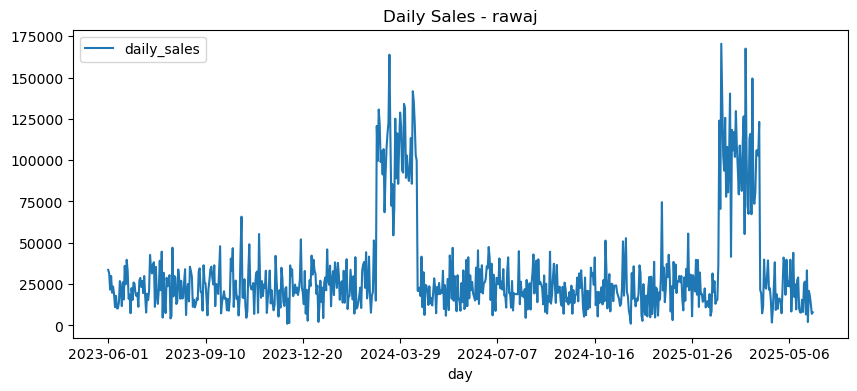

In [45]:
daily_sales = pd.read_sql(
    "SELECT DATE(order_date) AS day, SUM(total_amount) AS daily_sales FROM orders GROUP BY day ORDER BY day",
    sqlite_conn,
)
daily_sales.plot(x="day", y="daily_sales", figsize=(10, 4), title="Daily Sales - rawaj")

**Business question:** compare total revenue across governorates for the quarterly business review.

<Axes: title={'center': 'Total Revenue by Governorate'}, xlabel='governorate'>

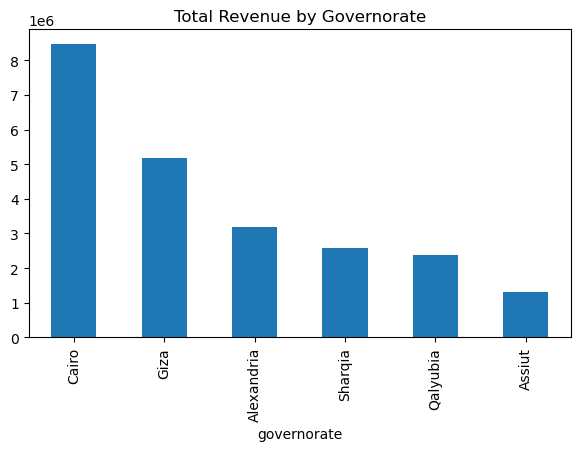

In [46]:
governorate_revenue = pd.read_sql(
    "SELECT g.governorate_name AS governorate, SUM(o.total_amount) AS total_revenue "
    "FROM orders o JOIN customers c ON o.customer_id = c.customer_id "
    "JOIN governorates g ON c.governorate_id = g.governorate_id "
    "GROUP BY g.governorate_name ORDER BY total_revenue DESC",
    sqlite_conn,
)
governorate_revenue.plot(
    x="governorate", y="total_revenue", kind="bar", figsize=(7, 4),
    title="Total Revenue by Governorate", legend=False,
)

**Business question:** marketing wants the channel mix for a campaign review — which channels drive the most web traffic, at a glance.

<Axes: title={'center': 'Web Events by Channel'}>

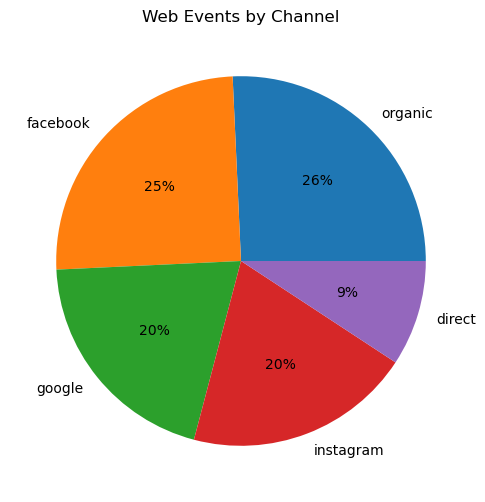

In [47]:
channel_events = pd.read_sql("SELECT channel FROM web_events", sqlite_conn)
channel_events["channel"].value_counts().plot(
    kind="pie", figsize=(6, 6), autopct="%1.0f%%", ylabel="",
    title="Web Events by Channel",
)

Three chart types, three real asks — a line for a trend over time, a bar for comparing categories, a pie for a proportional split. Same idea applies to virtually anything from the sweep above: get a DataFrame, call `.plot()`, pick the shape that fits the question.

## Section 5 — Passing parameters safely

Every query so far has had its filter values hardcoded. Real code usually takes that value from somewhere else — a form field, a function argument, another system — and the way you get it into the query matters, on any engine.

**Business question:** build a small function, `orders_for_customer(customer_id)`, that a dashboard could call with whatever customer a user picks.

**The wrong way — an f-string:**

In [48]:
def orders_for_customer_UNSAFE(customer_id):
    query = f"SELECT order_id, order_date, total_amount FROM orders WHERE customer_id = {customer_id}"
    return pd.read_sql(query, sqlite_conn)

orders_for_customer_UNSAFE(1).head()

,order_id,order_date,total_amount
0,1061,2024-10-18 21:01:28,2368.28
1,4409,2024-07-02 22:08:38,2231.18
2,4480,2025-03-06 13:01:40,1452.92
3,4999,2025-03-23 23:02:43,7709.14
4,5116,2023-06-23 17:07:32,8176.84


That works — until `customer_id` isn't a clean integer. Anything that reaches this function gets pasted directly into the SQL string:

In [49]:
malicious_input = "1 OR 1=1"
orders_for_customer_UNSAFE(malicious_input)

,order_id,order_date,total_amount
0,1,2024-03-16 21:07:35,1077.44
1,2,2025-02-23 19:03:32,2104.36
2,3,2023-06-10 17:56:51,1067.39
3,4,2025-03-25 23:13:06,2410.83
4,5,2023-08-12 12:42:08,4195.63
...,...,...,...
5995,5996,2025-04-07 13:58:38,8192.82
5996,5997,2024-02-16 23:26:46,5510.53
5997,5998,2024-07-10 15:58:20,6011.06
5998,5999,2025-02-24 13:29:23,2387.64


That returns **every order in the table**, not just customer 1's — the classic SQL injection pattern. The value was never meant to be SQL, but string-formatting it into the query let it become SQL.

**The right way — a bound parameter:**

In [50]:
def orders_for_customer(customer_id):
    query = "SELECT order_id, order_date, total_amount FROM orders WHERE customer_id = :cust_id"
    return pd.read_sql(query, sqlite_conn, params={"cust_id": customer_id})

orders_for_customer(1).head()

,order_id,order_date,total_amount
0,1061,2024-10-18 21:01:28,2368.28
1,4409,2024-07-02 22:08:38,2231.18
2,4480,2025-03-06 13:01:40,1452.92
3,4999,2025-03-23 23:02:43,7709.14
4,5116,2023-06-23 17:07:32,8176.84


In [51]:
malicious_input = "1 OR 1=1"
orders_for_customer(malicious_input)

,order_id,order_date,total_amount


That returns **zero rows**, not the malicious result — but notice it's a different kind of "safe" than MySQL's. Back in `day06_python_mysql.ipynb`, MySQL coerced the same string down to the leading number (`1`) and returned the normal, correct rows for that customer. SQLite is stricter: a text value never matches an integer column unless it's a clean number, so the malicious string just matches nothing. Both outcomes are equally safe — the value never got a chance to be parsed as SQL either way — they just fail differently, which is itself worth knowing before you assume one engine's error-handling behavior applies to the other.

`:cust_id` is a **placeholder**, not a slot for pasted text — the driver sends the query and the value to the database as two separate things, so the value is never parsed as SQL, no matter what it contains. This is the single most important habit in this notebook: **never build a query string with f-strings/`.format()`/`%`-formatting using a value that came from outside your own code.** Always use a placeholder (`:name`) and pass the value separately — no SQLAlchemy needed for this either, plain `sqlite3` supports named parameters natively, which is why the stored-procedure-equivalent function above already used `params={"cust_id": customer_id}`.

## Section 6 — MySQL vs SQLite: what actually differs

That sweep only needed to change syntax twice — date formatting and `LAG`'s date input. The full list of what's actually different:

| Need | MySQL | SQLite |
|---|---|---|
| Format a date | `DATE_FORMAT(col, '%Y-%m')` | `STRFTIME('%Y-%m', col)` |
| Year part of a date | `YEAR(col)` | `STRFTIME('%Y', col)` |
| Date difference | `DATEDIFF(d1, d2)` | no `DATEDIFF` — `JULIANDAY(d1) - JULIANDAY(d2)` |
| Concatenate strings | `CONCAT(a, b)` | `a \|\| b` (also `CONCAT` on SQLite 3.44+) |
| Auto-increment PK | `AUTO_INCREMENT` | `AUTOINCREMENT` |
| Stored procedures | `CREATE PROCEDURE` | not supported at all |

Everything else from the sweep above — JOINs, CASE, string functions, subqueries, CTEs, temp tables, views, and every window function (`RANK`/`DENSE_RANK`/`ROW_NUMBER`/`LAG`/`LEAD`) — ran completely unchanged.

## Recap & what's next

This closes the core curriculum. Days 07-10 apply everything from Days 01-05 — filtering, JOINs, CASE, string functions, subqueries, CTEs, window functions — against real SQLite datasets, with far less hand-holding. They'll connect the same way Section 3's Option 2 did here: a bare `%sql sqlite:///...` connection string, no SQLAlchemy required.